In [2]:
import os
import re
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from tqdm.auto import tqdm
import gc # Garbage collector để dọn RAM

# CONFIG & SETUP
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 128 # Test thì tăng batch size lên cho nhanh, không cần backprop
DATA_PATH = "/kaggle/input/cs213data/sarcasm.csv"
MODEL_DIR = "/kaggle/input/modelnlp"

print(f"Running Inference on {DEVICE}")

# MODEL CLASSES (BẮT BUỘC PHẢI KHAI BÁO LẠI)
class DistilBertBaseline(nn.Module):
    def __init__(self, model_name=MODEL_NAME, dropout=0.3):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(
            nn.Linear(self.bert.config.hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        hidden = out.last_hidden_state[:,0,:]
        return self.classifier(hidden).squeeze(-1)

class DualDistilBert(nn.Module):
    def __init__(self, model_name=MODEL_NAME, dropout=0.3):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(
            nn.Linear(self.bert.config.hidden_size * 2, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )
    def forward(self, input_ids_c, attention_mask_c, input_ids_p, attention_mask_p):
        out_c = self.bert(input_ids=input_ids_c, attention_mask=attention_mask_c).last_hidden_state[:, 0]
        out_p = self.bert(input_ids=input_ids_p, attention_mask=attention_mask_p).last_hidden_state[:, 0]
        x = torch.cat([out_c, out_p], dim=1)
        return self.classifier(x).squeeze(-1)

class DualDistilBertWithSentiment(nn.Module):
    def __init__(self, model_name=MODEL_NAME, dropout=0.3):
        super().__init__()
        self.bert_c = DistilBertModel.from_pretrained(model_name)
        self.bert_p = DistilBertModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(
            nn.Linear(self.bert_c.config.hidden_size * 2 + 3, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )
    def forward(self, input_ids_c, attention_mask_c, input_ids_p, attention_mask_p, sent_c, sent_p):
        o1 = self.bert_c(input_ids=input_ids_c, attention_mask=attention_mask_c).last_hidden_state[:,0,:]
        o2 = self.bert_p(input_ids=input_ids_p, attention_mask=attention_mask_p).last_hidden_state[:,0,:]
        sent_diff = (sent_c - sent_p).unsqueeze(1)
        sent_cat = torch.cat([sent_c.unsqueeze(1), sent_p.unsqueeze(1), sent_diff], dim=1)
        concat = torch.cat([o1, o2, sent_cat], dim=1)
        return self.classifier(concat).squeeze(-1)

# DATA PREPARATION FOR INFERENCE
def preprocess_text(text):
    if pd.isna(text): return ""
    return re.sub(r'\s+', ' ', str(text)).strip()

def compute_sentiment(text):
    try: return TextBlob(str(text)).sentiment.polarity
    except: return 0.0

class InferenceDataset(Dataset):
    def __init__(self, comments, parents, sentiments_c, sentiments_p, labels, tokenizer, max_len, mode):
        self.comments = comments
        self.parents = parents
        self.sent_c = sentiments_c
        self.sent_p = sentiments_p
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.mode = mode

    def __len__(self): return len(self.comments)

    def __getitem__(self, idx):
        item = {}
        c = str(self.comments[idx])
        p = str(self.parents[idx]) if self.parents is not None else ""
        
        if self.mode == 'level1':
            enc = self.tokenizer(c, truncation=True, padding='max_length', max_length=self.max_len, return_tensors='pt')
            item['input_ids'] = enc['input_ids'].squeeze(0)
            item['attention_mask'] = enc['attention_mask'].squeeze(0)
        else:
            enc_c = self.tokenizer(c, truncation=True, padding='max_length', max_length=self.max_len, return_tensors='pt')
            enc_p = self.tokenizer(p, truncation=True, padding='max_length', max_length=self.max_len, return_tensors='pt')
            item['input_ids_c'] = enc_c['input_ids'].squeeze(0)
            item['attention_mask_c'] = enc_c['attention_mask'].squeeze(0)
            item['input_ids_p'] = enc_p['input_ids'].squeeze(0)
            item['attention_mask_p'] = enc_p['attention_mask'].squeeze(0)
            
        if self.mode == 'level3' and self.sent_c is not None:
            item['sent_c'] = torch.tensor(self.sent_c[idx], dtype=torch.float)
            item['sent_p'] = torch.tensor(self.sent_p[idx], dtype=torch.float)
            
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item
        
print("Loading and Splitting Data...")
df = pd.read_csv(DATA_PATH)
df['comment_pp'] = df['comment'].fillna("").apply(preprocess_text)
df['parent_pp'] = df['parent_comment'].fillna("").apply(preprocess_text)
df['sentiment_comment'] = df['comment'].apply(compute_sentiment)
df['sentiment_parent'] = df['parent_comment'].apply(compute_sentiment)

_, df_test = train_test_split(df, test_size=0.1, random_state=42, stratify=df['label'])
print(f"Test Set Size: {len(df_test)}")

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# EVALUATION FUNCTION
def evaluate_saved_model(model_class, model_path, mode, level_name):
    print(f"\n--- Evaluating {level_name} ---")
    if not os.path.exists(model_path):
        print(f"File {model_path} not found!")
        return None

    # Tạo DataLoader
    ds = InferenceDataset(
        df_test['comment_pp'].tolist(),
        df_test['parent_pp'].tolist(),
        df_test['sentiment_comment'].values,
        df_test['sentiment_parent'].values,
        df_test['label'].values,
        tokenizer, MAX_LEN, mode
    )
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Load Model
    model = model_class()
    # Xử lý load weight từ DataParallel nếu có
    state_dict = torch.load(model_path, map_location=DEVICE)
    # Nếu file save có tiền tố "module.", cần bỏ đi để load vào model thường
    new_state_dict = {}
    for k, v in state_dict.items():
        name = k.replace("module.", "") 
        new_state_dict[name] = v
    model.load_state_dict(new_state_dict)
    
    model.to(DEVICE)
    model.eval()

    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dl, desc=f"Testing {level_name}"):
            if mode == 'level1':
                logits = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
            elif mode == 'level2':
                logits = model(
                    batch['input_ids_c'].to(DEVICE), batch['attention_mask_c'].to(DEVICE),
                    batch['input_ids_p'].to(DEVICE), batch['attention_mask_p'].to(DEVICE)
                )
            elif mode == 'level3':
                logits = model(
                    batch['input_ids_c'].to(DEVICE), batch['attention_mask_c'].to(DEVICE),
                    batch['input_ids_p'].to(DEVICE), batch['attention_mask_p'].to(DEVICE),
                    batch['sent_c'].to(DEVICE), batch['sent_p'].to(DEVICE)
                )
            
            preds = torch.sigmoid(logits).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['labels'].numpy())
    
    # Calculate Metrics
    bin_preds = [1 if p>=0.5 else 0 for p in all_preds]
    acc = accuracy_score(all_labels, bin_preds)
    f1 = f1_score(all_labels, bin_preds)
    
    print(f"{level_name} -> Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")
    
    # Clean memory
    del model
    torch.cuda.empty_cache()
    gc.collect()
    
    return {
        "name": level_name,
        "acc": acc,
        "f1": f1,
        "labels": all_labels,
        "probs": all_preds,
        "preds": bin_preds
    }


2026-01-04 18:46:25.903496: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767552386.104037      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767552386.158119      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767552386.589267      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767552386.589321      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767552386.589323      55 computation_placer.cc:177] computation placer alr

Running Inference on cuda
Loading and Splitting Data...
Test Set Size: 101083


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [2]:

# RUN EVALUATION & COMPARE
results = []

# --- LEVEL 1 ---
res1 = evaluate_saved_model(DistilBertBaseline, os.path.join(MODEL_DIR, "level1_distilbert.pt"), 'level1', "Level 1 (Comment Only)")
if res1: results.append(res1)

# --- LEVEL 2 ---
res2 = evaluate_saved_model(DualDistilBert, os.path.join(MODEL_DIR, "level2_dual.pt"), 'level2', "Level 2 (Dual Encoder)")
if res2: results.append(res2)

# --- LEVEL 3 ---
res3 = evaluate_saved_model(DualDistilBertWithSentiment, os.path.join(MODEL_DIR, "level3_dual_sent.pt"), 'level3', "Level 3 (+ Sentiment)")
if res3: results.append(res3)



--- Evaluating Level 1 (Comment Only) ---


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Testing Level 1 (Comment Only):   0%|          | 0/790 [00:00<?, ?it/s]

Level 1 (Comment Only) -> Accuracy: 0.7746 | F1-Score: 0.7732

--- Evaluating Level 2 (Dual Encoder) ---


Testing Level 2 (Dual Encoder):   0%|          | 0/790 [00:00<?, ?it/s]

Level 2 (Dual Encoder) -> Accuracy: 0.7824 | F1-Score: 0.7811

--- Evaluating Level 3 (+ Sentiment) ---


Testing Level 3 (+ Sentiment):   0%|          | 0/790 [00:00<?, ?it/s]

Level 3 (+ Sentiment) -> Accuracy: 0.7810 | F1-Score: 0.7805



=== FINAL LEADERBOARD ===
                     name       acc        f1
0  Level 1 (Comment Only)  0.774591  0.773182
1  Level 2 (Dual Encoder)  0.782387  0.781066
2   Level 3 (+ Sentiment)  0.781022  0.780522


/tmp/ipykernel_55/3906854913.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='f1', data=df_res, palette='viridis')


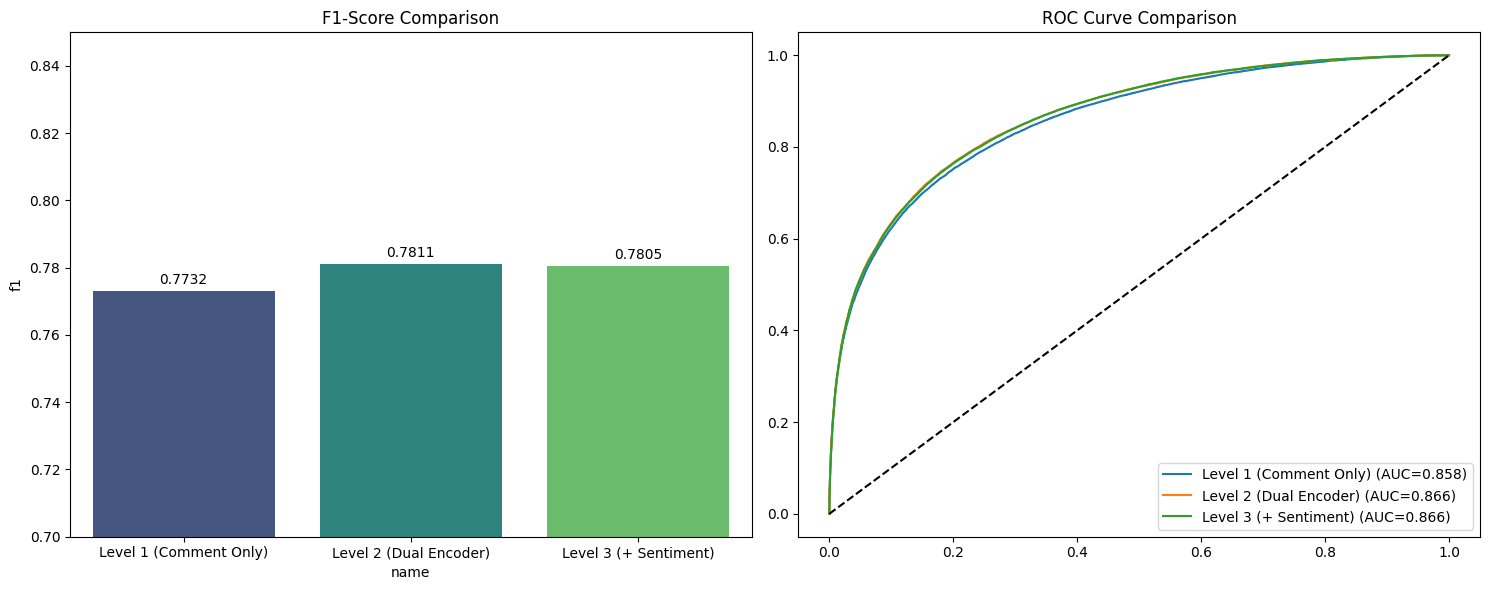

In [3]:
# VISUALIZATION
if results:
    # Bảng so sánh
    df_res = pd.DataFrame(results)[['name', 'acc', 'f1']]
    print("\n=== FINAL LEADERBOARD ===")
    print(df_res)
    
    plt.figure(figsize=(15, 6))
    
    # 1. Bar Chart Compare F1
    plt.subplot(1, 2, 1)
    sns.barplot(x='name', y='f1', data=df_res, palette='viridis')
    plt.title("F1-Score Comparison")
    plt.ylim(0.7, 0.85) # Zoom vào khoảng điểm số
    for index, row in df_res.iterrows():
        plt.text(index, row.f1 + 0.002, f"{row.f1:.4f}", ha='center', color='black')
        
    # 2. ROC Curve Comparison
    plt.subplot(1, 2, 2)
    for res in results:
        fpr, tpr, _ = roc_curve(res['labels'], res['probs'])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{res['name']} (AUC={roc_auc:.3f})")
    
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title("ROC Curve Comparison")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [28]:
import torch
import os
import re
import pandas as pd
from textblob import TextBlob
from transformers import DistilBertTokenizer

# --- 0. CẤU HÌNH THIẾT BỊ & TOKENIZER ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Đang chạy trên: {DEVICE}")

# Load Tokenizer (dùng chung cho cả 3 model)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# --- 1. CÁC HÀM HỖ TRỢ ---

def preprocess_text(text):
    if pd.isna(text): return ""
    text = str(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def compute_sentiment(text):
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0.0

def load_model_weights(model_instance, path, device):
    if not os.path.exists(path):
        print(f"⚠️  Lỗi: Không tìm thấy file '{path}'")
        return None
    
    try:
        # Load state_dict
        state_dict = torch.load(path, map_location=device)
        # Xử lý prefix "module." nếu có
        new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
        
        # Đẩy model lên device trước
        model_instance.to(device)
        # Load trọng số
        model_instance.load_state_dict(new_state_dict)
        # Tắt Dropout để dự đoán
        model_instance.eval() 
        return model_instance
    except Exception as e:
        print(f"❌ Lỗi khi load '{path}': {e}")
        return None

# --- 2. HÀM DỰ ĐOÁN CHÍNH (Đã khớp tên file) ---

def predict_sarcasm_demo_all(comment, parent_comment, model_dir="."):
    print(f"\n{'='*20} DEMO PREDICTION {'='*20}")
    print(f"📝 Context: \"{parent_comment}\"")
    print(f"💬 Reply:   \"{comment}\"")
    print(f"{'-'*75}")
    print(f"{'MODEL NAME':<30} | {'PROB':<10} | {'PREDICTION'}")
    print("-" * 75)

    # A. Tiền xử lý dữ liệu
    c_clean = preprocess_text(comment)
    p_clean = preprocess_text(parent_comment)

    # Tokenize
    inputs_c = tokenizer(c_clean, return_tensors='pt', padding='max_length', max_length=128, truncation=True)
    inputs_p = tokenizer(p_clean, return_tensors='pt', padding='max_length', max_length=128, truncation=True)

    # Chuyển sang device
    ids_c = inputs_c['input_ids'].to(DEVICE)
    mask_c = inputs_c['attention_mask'].to(DEVICE)
    ids_p = inputs_p['input_ids'].to(DEVICE)
    mask_p = inputs_p['attention_mask'].to(DEVICE)

    # Sentiment (Cho Level 3)
    val_c = compute_sentiment(c_clean)
    val_p = compute_sentiment(p_clean)
    # Lưu ý: tạo tensor [val] (1 chiều) để khớp với unsqueeze(1) trong model
    sent_c = torch.tensor([val_c], dtype=torch.float).to(DEVICE)
    sent_p = torch.tensor([val_p], dtype=torch.float).to(DEVICE)

    # B. Cấu hình danh sách Model (ĐÚNG TÊN FILE BẠN GỬI)
    models_list = [
        {
            "name": "Level 1 (Reply Only)",
            "instance": DistilBertBaseline(), 
            "filename": "/kaggle/input/modelnlp/level1_distilbert.pt",
            "type": 1
        },
        {
            "name": "Level 2 (Dual Encoder)",
            "instance": DualDistilBert(),
            "filename": "/kaggle/input/modelnlp/level2_dual.pt",
            "type": 2
        },
        {
            "name": "Level 3 (Dual + Sentiment)",
            "instance": DualDistilBertWithSentiment(),
            "filename": "/kaggle/input/modelnlp/level3_dual_sent.pt",
            "type": 3
        }
    ]

    # C. Chạy vòng lặp dự đoán
    for item in models_list:
        # Tạo đường dẫn file
        full_path = os.path.join(model_dir, item['filename'])
        
        # Load model
        model = load_model_weights(item['instance'], full_path, DEVICE)
        
        if model is None:
            print(f"{item['name']:<30} | {'MISSING':<10} | ❌ File not found")
            continue

        with torch.no_grad():
            logits = None
            
            # --- PHÂN LOẠI INPUT THEO TỪNG KIẾN TRÚC ---
            if item['type'] == 1:
                # Level 1: Chỉ nhận Reply
                logits = model(ids_c, mask_c)
            
            elif item['type'] == 2:
                # Level 2: Nhận Comment trước, Parent sau (theo class DualDistilBert)
                logits = model(ids_c, mask_c, ids_p, mask_p)
            
            elif item['type'] == 3:
                # Level 3: Nhận đủ 6 tham số
                logits = model(ids_c, mask_c, ids_p, mask_p, sent_c, sent_p)

            # Tính xác suất
            prob = torch.sigmoid(logits).item()
            label = "🎭 Sarcastic" if prob >= 0.5 else "😐 Normal"
            
            # In kết quả
            print(f"{item['name']:<30} | {prob:.4f}     | {label}")

    print("="*75 + "\n")

✅ Đang chạy trên: cuda


In [40]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
df_test[['label', 'comment', 'parent_comment']].head(20)

,label,comment,parent_comment
363677,0,I believe it.,"Keep up dude , were actually a 2nd world country now, don't believe me , drive through the housing areas in any us city , especially east coast,"
23101,0,Given the state of Labour it may well be a blessing.,"Are we now a one party state.. what does that say about our country now. Its pretty sad when i think Tories will be in Government for the next 4/8/12 years unless something drastic happens. The Tories can do what they want with a majority and they will have a majority until the left support PR, im more right wing but i still believe in alot of what the left stand for. The Sad thing is it doesn't matter what the left stand for unless they have a majority which wont happen for a while if ever. Its quite Depressing honestly."
52252,0,"The first Fw 190 is pretty good, those 20mm cannons shred the early spits you face","Liking the FW-190 A-5/U2 Switched back to my German line after spending some weeks with the Brit line. In the Brits, I found that I could do very little with the Tier III Spitfire Mk. Vc (BR 5.3 in AB). I had trouble getting guns on (in a Spit for Pete's sake !), and what I hit I rarely knocked down. This is even after getting the gun mods, and with good crew skills. So I figured that was conclusive proof that I suck at the air combat aspect of this game and should stick to killing bases and ground units. Now in a fully stock FW 190 A-5/U2 (BR 6.0 in AB) I am getting 3 air kills a game. I feel redeemed after so much frustration."
191291,0,Waste of a cast for a generic action movie,Assassin's Creed (2016) New Trailer - Jimmy Kimmel Live
926620,1,Isn't it nice when the people representing us refuse to listen to us?,"I'm in the same boat as you. I remember calling representatives when the SOPA/PIPA fiasco was going on, and I got three full answering machines in a row. I'm not sure if they are understaffed or just don't give a shit, but it is completely unacceptable."
535688,0,"I particularly liked the HEB commercial when his mom puts a bunch of salsa and cheese in a pot and JJ's all like, ""Whoa Ma"" with a really long 'a' on the end because he is from Wiscaansin.",Definitely my favorite Watt commercial thus far....
297897,1,hordes of M60 medics sure made a lot of sense,"Support's always been the black sheep class. And it's painful since it's my main class. I preferred Bad Company 2's class layout, where the 'Support' class in that game (Assault) actually had a viable gun to use effectively at range. Medics having the MG made sense, due to their focus being on healing and reviving, basically staying back. The ammo pack for Assault was only used sparingly, if at all."
137180,1,Because living in a community with underfunded education is totally a better option....,"Become an adult without kids and have to pay school taxes, you'll look at this differently."
120169,1,"Yeah, those damned directors, always out to make a buck with their fussy insistence on outdated technology that consumers care so much about.","But we're reinventing the wheel at that point. The cynical part of me thinks that he just wants the film to get revisited and looked at in a different way, much in the same way Tarantino likes to release his stuff on 35mm prints. It's not the ""true"" version so much as a kind of gimmicky way to re-experience the film. There's nothing particularly wrong with that, it's just not necessary. Like when they throw older blockbusters onto Imax, it's really kind of redundant."
20562,1,Yeah I could only imagine how less of savages we were outside the concrete jungle,"If you're able to recognise the emotional bond and sentience of an animal to the level that you're able to use it against itself, then one would hope you'd be able to recognise the animal for the ethical consideration it now deserves. The fact that this doesn't happen makes this whole thing extra grim. Not just for the dolphins, but what it tells us about the human condition as well."


In [51]:
predict_sarcasm_demo_all(
    comment="Obviously if someone dislikes it it means it's a bad game",
    parent_comment="Doesn't make it a bad game."
)
predict_sarcasm_demo_all(
    comment="Yeah, those damned directors, always out to make a buck with their fussy insistence on outdated technology that consumers care so much about.", 
    parent_comment="But we're reinventing the wheel at that point. The cynical part of me thinks that he just wants the film to get revisited and looked at in a different way, much in the same way Tarantino likes to release his stuff on 35mm prints. It's not the 'true' version so much as a kind of gimmicky way to re-experience the film. There's nothing particularly wrong with that, it's just not necessary. Like when they throw older blockbusters onto Imax, it's really kind of redundant."
)
predict_sarcasm_demo_all(
    comment="I believe it.", 
    parent_comment="Keep up dude , were actually a 2nd world country now, don't believe me , drive through the housing areas in any us city , especially east coast,"
)


==================== DEMO PREDICTION ====================
📝 Context: "Doesn't make it a bad game."
💬 Reply:   "Obviously if someone dislikes it it means it's a bad game"
---------------------------------------------------------------------------
MODEL NAME                     | PROB       | PREDICTION
---------------------------------------------------------------------------
Level 1 (Reply Only)           | 0.9886     | 🎭 Sarcastic
Level 2 (Dual Encoder)         | 0.9889     | 🎭 Sarcastic
Level 3 (Dual + Sentiment)     | 0.9890     | 🎭 Sarcastic


==================== DEMO PREDICTION ====================
📝 Context: "But we're reinventing the wheel at that point. The cynical part of me thinks that he just wants the film to get revisited and looked at in a different way, much in the same way Tarantino likes to release his stuff on 35mm prints. It's not the 'true' version so much as a kind of gimmicky way to re-experience the film. There's nothing particularly wrong with that, it's just

In [4]:
def load_model(model_class, model_path, device):
    model = model_class()
    state_dict = torch.load(model_path, map_location=device)
    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model
def predict_one(model, tokenizer, mode, comment, parent, device):
    with torch.no_grad():
        if mode == "level1":
            enc = tokenizer(preprocess_text(comment),
                            return_tensors="pt",
                            padding="max_length",
                            max_length=128,
                            truncation=True)
            logits = model(
                enc["input_ids"].to(device),
                enc["attention_mask"].to(device)
            )

        elif mode == "level2":
            enc_c = tokenizer(preprocess_text(comment),
                              return_tensors="pt",
                              padding="max_length",
                              max_length=128,
                              truncation=True)
            enc_p = tokenizer(preprocess_text(parent),
                              return_tensors="pt",
                              padding="max_length",
                              max_length=128,
                              truncation=True)
            logits = model(
                enc_c["input_ids"].to(device), enc_c["attention_mask"].to(device),
                enc_p["input_ids"].to(device), enc_p["attention_mask"].to(device)
            )

        elif mode == "level3":
            enc_c = tokenizer(preprocess_text(comment),
                              return_tensors="pt",
                              padding="max_length",
                              max_length=128,
                              truncation=True)
            enc_p = tokenizer(preprocess_text(parent),
                              return_tensors="pt",
                              padding="max_length",
                              max_length=128,
                              truncation=True)

            sent_c = torch.tensor([compute_sentiment(comment)], dtype=torch.float).to(device)
            sent_p = torch.tensor([compute_sentiment(parent)], dtype=torch.float).to(device)

            logits = model(
                enc_c["input_ids"].to(device), enc_c["attention_mask"].to(device),
                enc_p["input_ids"].to(device), enc_p["attention_mask"].to(device),
                sent_c, sent_p
            )

        prob = torch.sigmoid(logits).item()
        pred = 1 if prob >= 0.5 else 0
        return pred, prob
def get_comparative_errors(
    df_test,
    tokenizer,
    device,
    model_l1, model_l2, model_l3,
    max_samples=50
):
    results = []

    for _, row in df_test.iterrows():
        if len(results) >= max_samples:
            break

        comment = str(row["comment"])
        parent  = str(row["parent_comment"])
        label   = int(row["label"])

        p1, prob1 = predict_one(model_l1, tokenizer, "level1", comment, parent, device)
        p2, prob2 = predict_one(model_l2, tokenizer, "level2", comment, parent, device)
        p3, prob3 = predict_one(model_l3, tokenizer, "level3", comment, parent, device)

        # Đếm số model sai
        wrong = sum([
            p1 != label,
            p2 != label,
            p3 != label
        ])

        if wrong > 0:
            results.append({
                "parent": parent,
                "reply": comment,
                "label": label,
                "level1": (p1, prob1),
                "level2": (p2, prob2),
                "level3": (p3, prob3),
                "num_wrong": wrong
            })

    return results
def print_comparative_report(samples, top_k=10):
    print("\n==================== 🔍 PHÂN TÍCH LỖI SO SÁNH 3 MODEL ====================")

    for i, s in enumerate(samples[:top_k]):
        true_lbl = "MỈA MAI (1)" if s["label"] == 1 else "BÌNH THƯỜNG (0)"

        print(f"\n🔸 Mẫu #{i+1} | ❌ Số model sai: {s['num_wrong']}/3")
        print(f"Context: \"{s['parent']}\"")
        print(f"Reply:   \"{s['reply']}\"")
        print(f"Thực tế: {true_lbl}")

        for lvl in ["level1", "level2", "level3"]:
            pred, prob = s[lvl]
            pred_str = "MỈA MAI" if pred == 1 else "BÌNH THƯỜNG"
            mark = "❌" if pred != s["label"] else "✅"
            print(f"  {mark} {lvl.upper():7s}: {pred_str} (Prob={prob:.3f})")

        print("-" * 80)

model_l1 = load_model(DistilBertBaseline, "/kaggle/input/modelnlp/level1_distilbert.pt", DEVICE)
model_l2 = load_model(DualDistilBert, "/kaggle/input/modelnlp/level2_dual.pt", DEVICE)
model_l3 = load_model(DualDistilBertWithSentiment, "/kaggle/input/modelnlp/level3_dual_sent.pt", DEVICE)

samples = get_comparative_errors(
    df_test, tokenizer, DEVICE,
    model_l1, model_l2, model_l3,
    max_samples=50
)

# Sắp xếp: mẫu mà nhiều model sai nhất trước
samples = sorted(samples, key=lambda x: -x["num_wrong"])

print_comparative_report(samples, top_k=50)



==================== 🔍 PHÂN TÍCH LỖI SO SÁNH 3 MODEL ====================

🔸 Mẫu #1 | ❌ Số model sai: 3/3
Context: "Look at that fucking douchenozzle, he's using sunglasses that block out the sun. Fuck him"
Reply:   "No one else in the picture is bothered by the sun"
Thực tế: BÌNH THƯỜNG (0)
  ❌ LEVEL1 : MỈA MAI (Prob=0.722)
  ❌ LEVEL2 : MỈA MAI (Prob=0.633)
  ❌ LEVEL3 : MỈA MAI (Prob=0.728)
--------------------------------------------------------------------------------

🔸 Mẫu #2 | ❌ Số model sai: 3/3
Context: "Yup. There are few players who manage to reach 10 yellow cards per season, so few are aware of this rule. Also, the card count is for all competitions within the Football Association, meaning that it covers the league as well as all association-sanctioned cups."
Reply:   "I bet Feillani (sp) knows all about the rule"
Thực tế: BÌNH THƯỜNG (0)
  ❌ LEVEL1 : MỈA MAI (Prob=0.869)
  ❌ LEVEL2 : MỈA MAI (Prob=0.844)
  ❌ LEVEL3 : MỈA MAI (Prob=0.922)
-----------------------------------